<div style="background-color:#FFECB3; color:black; padding:10px; border-radius:5px;">

Entrainement du modèle de base avec la gestion classique des données. C'est à dire séparation entre l'entrainement et le test de 80% 20% et augmentation des données uniquement sur les données d'entrainement.



</div>

In [1]:
%%time
import time

NOTEBOOK_NAME = "car-damage-severity-mobilenetv2 classique V1"                    #Sert à nommer le modèle sauvé

# Installations

# pip install tensorflow
# pip install Pillow
# pip install matplotlib
# pip install scikit-learn
# pip install seaborn
# pip install pydot


# Bibliothèques principales
import numpy as np
from pathlib import Path
import os
from PIL import Image
import shutil
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import json


# TensorFlow et Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import clone_model
from tensorflow.keras.utils import plot_model
from tensorflow.keras.utils import load_img

# Configuration GPU
try:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU(s) détecté(s): {len(gpus)} - Croissance mémoire activée")
    else:
        print("⚠️  Aucun GPU détecté - Utilisation du CPU (entraînement sera lent)")
except Exception as e:
    print(f"Configuration GPU: {e}")


# Reproductibilité
tf.random.set_seed(55)
np.random.seed(55)    
SEED = 55

print(f"\n📦 Versions des bibliothèques :")
print(f"  - TensorFlow : {tf.__version__}")
print(f"  - Keras      : {keras.__version__}")
print(f"  - NumPy      : {np.__version__}")

⚠️  Aucun GPU détecté - Utilisation du CPU (entraînement sera lent)

📦 Versions des bibliothèques :
  - TensorFlow : 2.21.0
  - Keras      : 3.13.2
  - NumPy      : 2.4.4
CPU times: total: 3.61 s
Wall time: 13.8 s


<div style="background-color:#FFECB3; color:black; padding:10px; border-radius:5px;">

Gestion du Dataset<br><br>

La préparation est classique avec normalisation à 224 pixels en couleurs et le rapport de 80% entre la partie entrainement et la partie test.
Augmenation seulement sur les données d'entrainement.

</div>

---------------------------------------------------------
# Dataset 
---------------------------------------------------------

In [2]:
%%time
# dataset

project_root = Path.cwd().parent
print("project_root : " + str(project_root))

data_dir = str(project_root) + "/CarDamageSeverityDataset"
data_dir = Path(data_dir)
print("data_dir:", data_dir)

IMG_SIZE = (224, 224)


project_root : c:\Users\huber_otpq54a\OneDrive\Documents\Formation\IA\Developpement\Projets\Deep_Learning
data_dir: c:\Users\huber_otpq54a\OneDrive\Documents\Formation\IA\Developpement\Projets\Deep_Learning\CarDamageSeverityDataset
CPU times: total: 0 ns
Wall time: 0 ns


In [3]:
"""

%%time
# Augmentation 

# CONFIG
INPUT_DIR = data_dir
OUTPUT_DIR = Path(str(project_root) + "/CarDamageSeverityDatasetAugmented")
AUG_PER_IMAGE = 5  # nombre d'images générées par image

# AUGMENTATION
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomBrightness(0.2),
])

# CRÉER DOSSIERS
os.makedirs(OUTPUT_DIR, exist_ok=True)

# TRAITEMENT
for class_name in os.listdir(INPUT_DIR):
    class_input_path = os.path.join(INPUT_DIR, class_name)
    class_output_path = os.path.join(OUTPUT_DIR, class_name)

    os.makedirs(class_output_path, exist_ok=True)

    for img_name in os.listdir(class_input_path):
        img_path = os.path.join(class_input_path, img_name)

        # Charger image
        img = Image.open(img_path).resize(IMG_SIZE)
        img_array = np.array(img)
        img_array = np.expand_dims(img_array, axis=0)  # batch dimension

        # Sauvegarder image originale (optionnel)
        base_name = os.path.splitext(img_name)[0]

        for i in range(AUG_PER_IMAGE):
            augmented = data_augmentation(img_array, training=True)

            # Convertir en image
            aug_img = augmented[0].numpy().astype("uint8")
            aug_img = Image.fromarray(aug_img)

            # Sauvegarde
            new_name = f"{base_name}_aug_{i}.jpg"
            aug_img.save(os.path.join(class_output_path, new_name))

print("Dataset augmenté créé ✅")
"""



'\n\n%%time\n# Augmentation \n\n# CONFIG\nINPUT_DIR = data_dir\nOUTPUT_DIR = Path(str(project_root) + "/CarDamageSeverityDatasetAugmented")\nAUG_PER_IMAGE = 5  # nombre d\'images générées par image\n\n# AUGMENTATION\ndata_augmentation = keras.Sequential([\n    layers.RandomFlip("horizontal"),\n    layers.RandomRotation(0.2),\n    layers.RandomZoom(0.2),\n    layers.RandomTranslation(0.1, 0.1),\n    layers.RandomBrightness(0.2),\n])\n\n# CRÉER DOSSIERS\nos.makedirs(OUTPUT_DIR, exist_ok=True)\n\n# TRAITEMENT\nfor class_name in os.listdir(INPUT_DIR):\n    class_input_path = os.path.join(INPUT_DIR, class_name)\n    class_output_path = os.path.join(OUTPUT_DIR, class_name)\n\n    os.makedirs(class_output_path, exist_ok=True)\n\n    for img_name in os.listdir(class_input_path):\n        img_path = os.path.join(class_input_path, img_name)\n\n        # Charger image\n        img = Image.open(img_path).resize(IMG_SIZE)\n        img_array = np.array(img)\n        img_array = np.expand_dims(img_ar

In [4]:
"""

%%time
# Creation dataset complet : original + augmenté

data_dir_complet = str(project_root) + "/CarDamageSeverityDatasetComplet"
data_dir_complet = Path(data_dir_complet)
print("data_dir_complet :", data_dir_complet)

shutil.copytree(str(data_dir), str(data_dir_complet), dirs_exist_ok=True)   
shutil.copytree(str(OUTPUT_DIR), str(data_dir_complet), dirs_exist_ok=True)   

"""


'\n\n%%time\n# Creation dataset complet : original + augmenté\n\ndata_dir_complet = str(project_root) + "/CarDamageSeverityDatasetComplet"\ndata_dir_complet = Path(data_dir_complet)\nprint("data_dir_complet :", data_dir_complet)\n\nshutil.copytree(str(data_dir), str(data_dir_complet), dirs_exist_ok=True)   \nshutil.copytree(str(OUTPUT_DIR), str(data_dir_complet), dirs_exist_ok=True)   \n\n'

In [5]:
%%time
# Analyse Dataset 

def analyse_dataset(p_chemin):

    # Explorer la structure
    print("\n📂 Structure du dataset : ", p_chemin)
    all_items = sorted([item.name for item in p_chemin.glob('*') if item.is_dir()])
    print(f"  - Tous les dossiers trouvés : {all_items}")

    class_names = all_items
    class_names = sorted(class_names)

    print(f"  - Nombre de classes : {len(class_names)}")

    if len(class_names) != 4:
        print("\n⚠️  Attention : Nombre de classes incorrect !")
        print("   Vérification du contenu du dataset...")

    # Compter les images par classe
    print("\n📊 Distribution des images par classe :")
    class_counts = {}
    total_images = 0
    for class_name in class_names:
        class_path = p_chemin / class_name
        count = len(list(class_path.glob('*.*')))
        class_counts[class_name] = count
        total_images += count
        print(f"  - {class_name:15s} : {count:4d} images")

    print(f"\n  - Total : {total_images} images")
    print(f"  - Moyenne par classe : {total_images / len(class_names):.0f} images")

    return class_names

class_names = analyse_dataset(data_dir)

"""class_names = analyse_dataset(data_dir_complet)"""



📂 Structure du dataset :  c:\Users\huber_otpq54a\OneDrive\Documents\Formation\IA\Developpement\Projets\Deep_Learning\CarDamageSeverityDataset
  - Tous les dossiers trouvés : ['00-normal', '01-minor', '02-moderate', '03-severe']
  - Nombre de classes : 4

📊 Distribution des images par classe :
  - 00-normal       :  633 images
  - 01-minor        :  550 images
  - 02-moderate     :  552 images
  - 03-severe       :  580 images

  - Total : 2315 images
  - Moyenne par classe : 579 images
CPU times: total: 46.9 ms
Wall time: 6.06 ms


'class_names = analyse_dataset(data_dir_complet)'

In [6]:
%%time
#Préparation des datasets

"""data_dir = data_dir_complet"""


# Paramètres
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2

# Créer le dataset d'entraînement avec filtrage des classes
train_ds = image_dataset_from_directory(
    data_dir,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,       # redimensionne toutes les images automatiquement
    batch_size=BATCH_SIZE,     # nombre d’images envoyées au modèle à chaque itération
    label_mode='categorical',  # One-hot encoding pour multi-classe
    class_names=class_names
)

# for images, labels in train_ds:
#     print(images.shape, "   ", labels.shape)  # (32, 224, 224, 3)         (32, nb_classes)
    
# Créer le dataset de validation avec les mêmes classes
val_ds = image_dataset_from_directory(
    data_dir,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    class_names=class_names  # Même ordre de classes
)

print(f"\n  - Train batches  : {len(train_ds)}")
print(f"  - Val batches    : {len(val_ds)}")
print(f"  - Batch size     : {BATCH_SIZE}")
print(f"  - Image size     : {IMG_SIZE}")
print(f"\n  - Train samples  : ~{len(train_ds) * BATCH_SIZE}")
print(f"  - Val samples    : ~{len(val_ds) * BATCH_SIZE}")

Found 2315 files belonging to 4 classes.
Using 1852 files for training.
Found 2315 files belonging to 4 classes.
Using 463 files for validation.

  - Train batches  : 58
  - Val batches    : 15
  - Batch size     : 32
  - Image size     : (224, 224)

  - Train samples  : ~1856
  - Val samples    : ~480
CPU times: total: 172 ms
Wall time: 169 ms


In [7]:
%%time
# Prétraitement et (Data Augmentation)

# Créer un modèle d'augmentation de données plus agressif
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.3),
    layers.RandomZoom(height_factor=0.2, width_factor=0.2),
    layers.RandomTranslation(height_factor=0.2, width_factor=0.2),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(factor=0.2),
], name="data_augmentation")


# Fonction pour appliquer le prétraitement
def prepare_dataset(ds, augment=False, shuffle=True):
    # Normalisation MobileNetV2
    normalization = lambda x, y: (preprocess_input(x), y)
    ds = ds.map(normalization, num_parallel_calls=tf.data.AUTOTUNE)
    
    # Augmentation (seulement pour le train)
    if augment:
        augmentation = lambda x, y: (data_augmentation(x, training=True), y)
        ds = ds.map(augmentation, num_parallel_calls=tf.data.AUTOTUNE)
    
    # Shuffle pour le training
    if shuffle:
        ds = ds.shuffle(1000)
    
    # Optimisation des performances
    ds = ds.cache()  # Cache en mémoire
    ds = ds.prefetch(buffer_size=tf.data.AUTOTUNE)  # Prefetch pour accélérer
    
    return ds

# Appliquer le prétraitement
"""train_ds_prepared = prepare_dataset(train_ds, augment=False, shuffle=True)       """
train_ds_prepared = prepare_dataset(train_ds, augment=True, shuffle=True)  #mélange les données à chaque epoch     
val_ds_prepared = prepare_dataset(val_ds, augment=False, shuffle=False)

print(f"\n  - Train batches  : {len(train_ds_prepared)}")
print(f"  - Val batches    : {len(val_ds_prepared)}")
print(f"\n  - Train samples  : ~{len(train_ds_prepared) * BATCH_SIZE}")
print(f"  - Val samples    : ~{len(val_ds_prepared) * BATCH_SIZE}")

Cause: could not parse the source code of <function prepare_dataset.<locals>.<lambda> at 0x000001BB8E26A340>: no matching AST found among candidates:

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the source code of <function prepare_dataset.<locals>.<lambda> at 0x000001BB8E26A340>: no matching AST found among candidates:

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the source code of <function prepare_dataset.<locals>.<lambda> at 0x000001BB8E1D71A0>: no matching AST found among candidates:

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the source code of <function prepare_dataset.<locals>.<lambda> at 0x000001BB8E1D71A0>: no matching AST found among candidates:

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not par

<div style="background-color:#FFECB3; color:black; padding:10px; border-radius:5px;">

Chargement du modele MobileNetV2<br>

Ce modèle est choisi pour sa légèreté et donc sa rapidité d'entrainement. Il donne malgrès tout des résultats corrects dans notre cas de classification.
</div>

-------------------------------
# Modèle
-------------------------------

In [8]:
%%time

# Chargement MobileNetV2 pré-entraîné sans le classifier (include_top=False)
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,  # Exclure la couche de classification ImageNet
    weights='imagenet',  # Charger les poids pré-entraînés sur ImageNet
    pooling='avg'  # Global Average Pooling à la fin
)

# Verouillage de toutes les couches une à une pour que ça apparaisse correctement à l'affichage des couches
for i, layer in enumerate(base_model.layers):
    layer.trainable = False

    
print("✅ Modèle MobileNetV2 chargé !\n")

# Afficher la structure du modèle
print("📋 Structure du modèle MobileNetV2 :")
print(f"  - Architecture   : MobileNetV2")
print(f"  - Input shape    : (224, 224, 3)")
print(f"  - Poids          : ImageNet (1000 classes)")
print(f"  - Output shape   : {base_model.output_shape}")
print(f"  - Nombre de couches : {len(base_model.layers)}")

# Compter les paramètres
total_params = base_model.count_params()
print(f"\n  - Nombre total de paramètres : {total_params:,}")
print(f"  - Taille en mémoire (approx.) : {total_params * 4 / (1024**2):.1f} MB")


✅ Modèle MobileNetV2 chargé !

📋 Structure du modèle MobileNetV2 :
  - Architecture   : MobileNetV2
  - Input shape    : (224, 224, 3)
  - Poids          : ImageNet (1000 classes)
  - Output shape   : (None, 1280)
  - Nombre de couches : 155

  - Nombre total de paramètres : 2,257,984
  - Taille en mémoire (approx.) : 8.6 MB
CPU times: total: 531 ms
Wall time: 531 ms


In [9]:
%%time
print("🔍 Aperçu des couches de MobileNetV2\n")
print("="*80)

# Fonction helper pour obtenir l'output shape
def get_output_shape(layer):
    try:
        if hasattr(layer, 'output_shape'):
            return str(layer.output_shape)
        elif hasattr(layer, 'output'):
            return str(layer.output.shape)
        else:
            return "N/A"
    except:
        return "N/A"

def affiche_couches(p_model):
    # Afficher les 15 premières et 15 dernières couches
    print("\n📌 Premières couches (extraction de features bas niveau) :")
    for i, layer in enumerate(p_model.layers[:15]):
        output_shape = get_output_shape(layer)
        print(f"  {i+1:3d}. {layer.name:40s} | Output: {output_shape:30s} | Trainable: {layer.trainable}")

    print("\n      ...")

    print("\n📌 Dernières couches (features haut niveau) :")
    for i, layer in enumerate(p_model.layers[-15:], start=len(p_model.layers)-15):
        output_shape = get_output_shape(layer)
        print(f"  {i+1:3d}. {layer.name:40s} | Output: {output_shape:30s} | Trainable: {layer.trainable}")

    print("\n" + "="*80)

#affiche_couches(base_model)

def print_layers(p_model, n=0):
    for i, layer in enumerate(p_model.layers):
        # print(prefix + layer.name)
        output_shape = get_output_shape(layer)
        if n==0:
            print(f"  {i+1:3d}. {layer.name:40s} | Output: {output_shape:30s} | Trainable: {layer.trainable}")
        else:
            print(f"  {n:3d}.  {i+1:3d}. {layer.name:40s} | Output: {output_shape:30s} | Trainable: {layer.trainable}")
        if hasattr(layer, "layers"):  # modèle imbriqué
            x = i + 1
            print_layers(layer, x)

print_layers(base_model)

🔍 Aperçu des couches de MobileNetV2

    1. input_layer_1                            | Output: (None, 224, 224, 3)            | Trainable: False
    2. Conv1                                    | Output: (None, 112, 112, 32)           | Trainable: False
    3. bn_Conv1                                 | Output: (None, 112, 112, 32)           | Trainable: False
    4. Conv1_relu                               | Output: (None, 112, 112, 32)           | Trainable: False
    5. expanded_conv_depthwise                  | Output: (None, 112, 112, 32)           | Trainable: False
    6. expanded_conv_depthwise_BN               | Output: (None, 112, 112, 32)           | Trainable: False
    7. expanded_conv_depthwise_relu             | Output: (None, 112, 112, 32)           | Trainable: False
    8. expanded_conv_project                    | Output: (None, 112, 112, 16)           | Trainable: False
    9. expanded_conv_project_BN                 | Output: (None, 112, 112, 16)           | Trainabl

In [10]:
%%time
# Feature Extraction : Transfert-Learning

# Obtenir les noms de classes
class_names = train_ds.class_names
num_classes = len(class_names)
print(f"  - Classes        : {class_names}")
print(f"  - Nombre de classes : {num_classes}")

# Geler le modèle de base
base_model.trainable = False

# Architecture OPTIMALE pour ce dataset
inputs = keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)

# Classifier avec régularisation modérée
x = layers.Dropout(0.3)(x)  # Dropout modéré
x = layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01))(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model_frozen = keras.Model(inputs, outputs, name='MobileNetV2_Frozen')

# Compiler avec LR optimal
model_frozen.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),  # LR standard
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=2, name='top2_accuracy')]
)

print("\n✅ Modèle compilé !\n")

trainable = sum([tf.size(w).numpy() for w in model_frozen.trainable_weights])
non_trainable = sum([tf.size(w).numpy() for w in model_frozen.non_trainable_weights])
print(f"  - Paramètres entraînables    : {trainable:,}")
print(f"  - Paramètres non-entraînables: {non_trainable:,}")
print(f"  - Total                      : {trainable + non_trainable:,}")

model_frozen.summary()

  - Classes        : ['00-normal', '01-minor', '02-moderate', '03-severe']
  - Nombre de classes : 4

✅ Modèle compilé !

  - Paramètres entraînables    : 328,964
  - Paramètres non-entraînables: 2,257,984
  - Total                      : 2,586,948


Model: "MobileNetV2_Frozen"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,948 (9.87 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

CPU times: total: 78.1 ms
Wall time: 56.4 ms


<div style="background-color:#FFECB3; color:black; padding:10px; border-radius:5px;">

Entraînement du modèle en mode gelé<br>

Cette première étape va permettre d'utiliser le modèle pré-entrainé tel quel 
en ne rajoutant en fin que des couches permettant notre classification en 4 classes.
</div>

--------------------
# Entraînement du modèle frozen
--------------------

In [11]:
%%time

# Callbacks
early_stopping = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,  # Patience raisonnable
    restore_best_weights=True,
    mode='max',
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-7,
    verbose=1
)

checkpoint = callbacks.ModelCheckpoint(
    'best_model_frozen.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=0
)

EPOCHS_FROZEN = 30

history_frozen = model_frozen.fit(
    train_ds_prepared,
    validation_data=val_ds_prepared,
    epochs=EPOCHS_FROZEN,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=1
)

print("\n✅ Entraînement frozen terminé !")
print(f"   Epochs effectués : {len(history_frozen.history['loss'])}")

best_val_acc = max(history_frozen.history['val_accuracy'])
best_epoch = history_frozen.history['val_accuracy'].index(best_val_acc) + 1
print(f"   Meilleure val_accuracy : {best_val_acc*100:.2f}% (epoch {best_epoch})")

if best_val_acc < 0.70:
    print(f"\n⚠️  Accuracy de {best_val_acc*100:.1f}% est en dessous de 70%")
    print("   Le modèle pourrait bénéficier de plus d'entraînement.")
elif best_val_acc < 0.80:
    print(f"\n✅ Bon résultat : {best_val_acc*100:.1f}%")
else:
    print(f"\n🎯 Excellent ! Accuracy de {best_val_acc*100:.1f}%")
    

Epoch 1/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 16s 203ms/step - accuracy: 0.2630 - loss: 4.1528 - top2_accuracy: 0.5086 - val_accuracy: 0.2570 - val_loss: 3.0995 - val_top2_accuracy: 0.5119 - learning_rate: 0.0010
Epoch 2/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 196ms/step - accuracy: 0.2867 - loss: 2.5264 - top2_accuracy: 0.5524 - val_accuracy: 0.2246 - val_loss: 2.5487 - val_top2_accuracy: 0.4168 - learning_rate: 0.0010
Epoch 3/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 197ms/step - accuracy: 0.2835 - loss: 2.0809 - top2_accuracy: 0.5400 - val_accuracy: 0.2117 - val_loss: 2.1372 - val_top2_accuracy: 0.4644 - learning_rate: 0.0010
Epoch 4/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 12s 202ms/step - accuracy: 0.3126 - loss: 1.8469 - top2_accuracy: 0.5605 - val_accuracy: 0.2138 - val_loss: 1.8743 - val_top2_accuracy: 0.5940 - learning_rate: 0.0010
Epoch 5/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 12s 199ms/step - accuracy: 0.3072 - loss: 1.7132 - top2_accuracy: 0.5605 - val_accuracy: 0.2160 - val_loss: 1.7642 - val_top2_accuracy: 0.6026

<div style="background-color:#FFECB3; color:black; padding:10px; border-radius:5px;">

Evaluation de cet entrainement<br>

</div>

Epoch optimal détecté : 9 avec val_loss = 1.5140


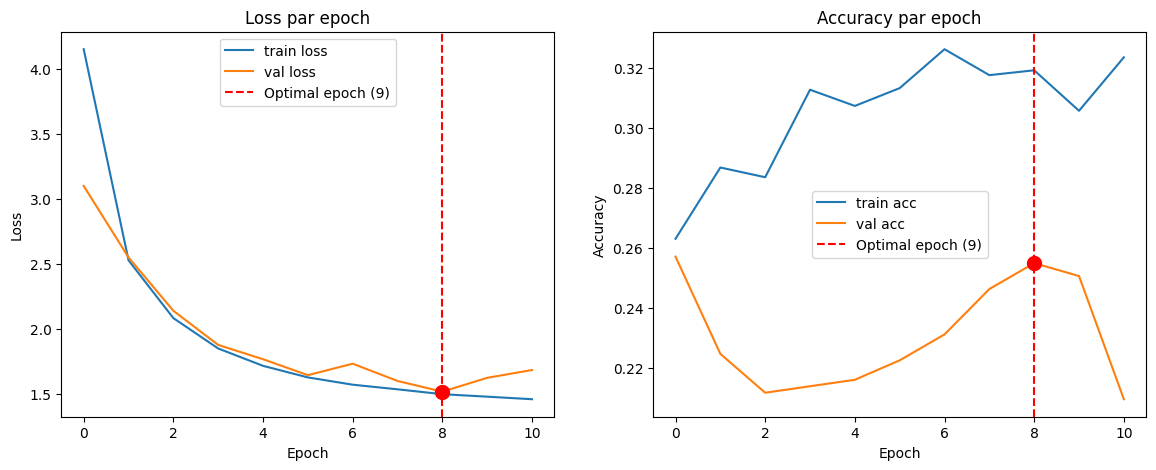

CPU times: total: 172 ms
Wall time: 253 ms


In [12]:
%%time

def evaluation(p_history):
    # Epoch optimal (val_loss minimal)
    val_loss = p_history.history['val_loss']
    optimal_epoch = np.argmin(val_loss)
    optimal_val_loss = val_loss[optimal_epoch]
    print(f"Epoch optimal détecté : {optimal_epoch + 1} avec val_loss = {optimal_val_loss:.4f}")

    # Tracer loss et accuracy avec repère
    plt.figure(figsize=(14,5))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(p_history.history['loss'], label='train loss')
    plt.plot(p_history.history['val_loss'], label='val loss')
    plt.axvline(optimal_epoch, color='r', linestyle='--', label=f'Optimal epoch ({optimal_epoch + 1})')
    plt.scatter(optimal_epoch, optimal_val_loss, color='red', s=100, zorder=5)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss par epoch')
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(p_history.history['accuracy'], label='train acc')
    plt.plot(p_history.history['val_accuracy'], label='val acc')
    plt.axvline(optimal_epoch, color='r', linestyle='--', label=f'Optimal epoch ({optimal_epoch + 1})')
    plt.scatter(optimal_epoch, p_history.history['val_accuracy'][optimal_epoch], color='red', s=100, zorder=5)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy par epoch')
    plt.legend()

    plt.show()

evaluation(history_frozen)

15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 201ms/step


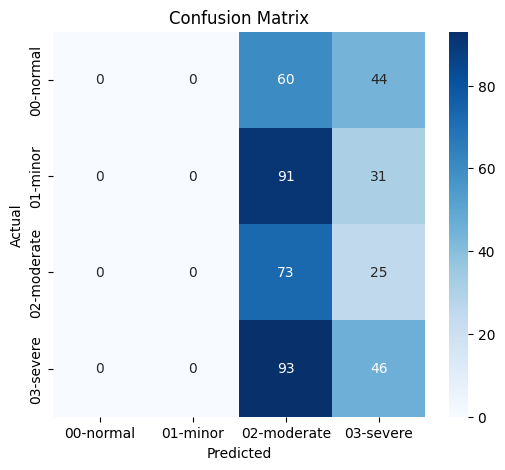

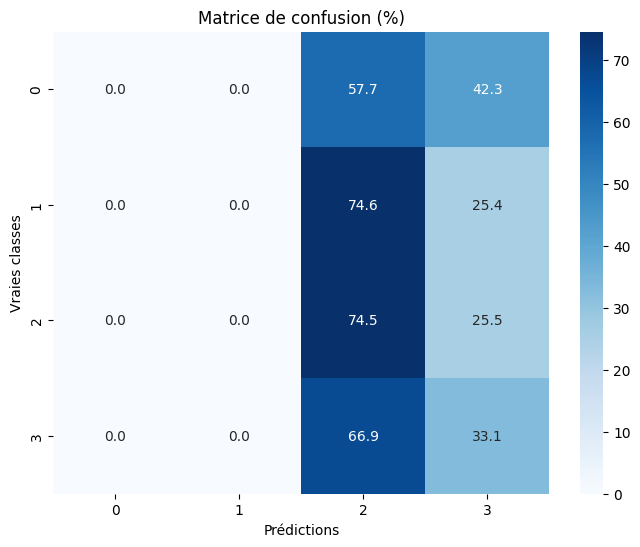


📄 Rapport de classification détaillé :

              precision    recall  f1-score   support

   00-normal      0.000     0.000     0.000       104
    01-minor      0.000     0.000     0.000       122
 02-moderate      0.230     0.745     0.352        98
   03-severe      0.315     0.331     0.323       139

    accuracy                          0.257       463
   macro avg      0.136     0.269     0.169       463
weighted avg      0.143     0.257     0.171       463

CPU times: total: 30 s
Wall time: 4.26 s


c:\Users\huber_otpq54a\OneDrive\Documents\Formation\IA\Developpement\Projets\Deep_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\huber_otpq54a\OneDrive\Documents\Formation\IA\Developpement\Projets\Deep_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\huber_otpq54a\OneDrive\Documents\Formation\IA\Developpement\Projets\Deep_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and

In [13]:
%%time
# Matrice de confusion

def matrice_confusion(p_model, p_dataset):
    y_val = np.concatenate([y for x, y in p_dataset], axis=0)
    y_val = np.argmax(y_val, axis=1)
    y_pred_probs = p_model.predict(p_dataset)
    y_pred_classes = np.argmax(y_pred_probs, axis=1)

    cm = confusion_matrix(y_val, y_pred_classes)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    # Normalisation par ligne (chaque ligne = 100%)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    # Conversion en pourcentage
    cm_percent = cm_norm * 100

    # Affichage
    plt.figure(figsize=(8,6))
    sns.heatmap(cm_percent, 
                annot=True, 
                fmt=".1f", 
                cmap="Blues")

    plt.xlabel('Prédictions')
    plt.ylabel('Vraies classes')
    plt.title('Matrice de confusion (%)')

    plt.show()

    # Rapport de classification
    print("\n📄 Rapport de classification détaillé :\n")
    print(classification_report(y_val, y_pred_classes, target_names=class_names, digits=3))


matrice_confusion(model_frozen, val_ds_prepared)


<div style="background-color:#FFECB3; color:black; padding:10px; border-radius:5px;">

Fine-Tuning<br>

Dans cette étape on va dégeler une partie des couches du modèle et l'entrainer en gardant un coefficiant de correction des poids du modèle initial très bas pour ne pas perturber le pré-entrainement initial mais en applicant quand même de petites corrections correspondant à nos données propres. 
</div>

--------------------------
# Fine-Tuning
--------------------------

In [14]:
%%time

# Évaluation AVANT fine-tuning
print("📈 Performance AVANT fine-tuning :")
results_before = model_frozen.evaluate(val_ds_prepared, verbose=0)
print(f"  - Accuracy : {results_before[1]*100:.2f}%")
print(f"  - Loss     : {results_before[0]:.4f}\n")

# clone du modèle avec ses poids
# model_finetuned = clone_model(model_frozen)
# model_finetuned.set_weights(model_frozen.get_weights())

# Dégeler le base_model
base_model.trainable = True

# Geler seulement les 100 premières couches
fine_tune_at = 100

for i, layer in enumerate(base_model.layers):
    if i < fine_tune_at:
        layer.trainable = False
    else:
        layer.trainable = True

print(f"📊 Configuration du dégel :")
print(f"  - Couches frozen  : {fine_tune_at}")
print(f"  - Couches unfrozen: {len(base_model.layers) - fine_tune_at}")

# Compter les paramètres
trainable_count = sum([tf.size(w).numpy() for w in model_frozen.trainable_weights])
non_trainable_count = sum([tf.size(w).numpy() for w in model_frozen.non_trainable_weights])
total = trainable_count + non_trainable_count

print(f"  - Paramètres entraînables : {trainable_count:,} ({trainable_count/total*100:.1f}%)")
print(f"  - Paramètres frozen       : {non_trainable_count:,}\n")

# Recompiler avec un LR très faible
FINE_TUNE_LR = 1e-5  # LR très faible

model_frozen.compile(
    optimizer=optimizers.Adam(learning_rate=FINE_TUNE_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=2, name='top2_accuracy')]
)

# Le modèle fine-tuned est le modèle frozen modifié
model_finetuned = model_frozen

print_layers(model_finetuned)

print(f"✅ Modèle recompilé avec LR = {FINE_TUNE_LR}")
print("\n💡 Le modèle va continuer depuis les poids déjà appris.")

# Vérification immédiate
print("\n🔍 Vérification immédiate :")
results_after_compile = model_finetuned.evaluate(val_ds_prepared, verbose=0)
print(f"  - Accuracy : {results_after_compile[1]*100:.2f}%")
print(f"  - Loss     : {results_after_compile[0]:.4f}")

if abs(results_after_compile[1] - results_before[1]) < 0.01:
    print(f"\n  ✅ Parfait ! Les poids sont préservés ({results_after_compile[1]*100:.1f}%)")
else:
    print(f"\n  ⚠️  Les performances ont changé après recompilation")

📈 Performance AVANT fine-tuning :
  - Accuracy : 25.70%
  - Loss     : 3.0995

📊 Configuration du dégel :
  - Couches frozen  : 100
  - Couches unfrozen: 55
  - Paramètres entraînables : 2,190,404 (84.7%)
  - Paramètres frozen       : 396,544

    1. input_layer_2                            | Output: (None, 224, 224, 3)            | Trainable: True
    2. mobilenetv2_1.00_224                     | Output: (None, 1280)                   | Trainable: True
    2.    1. input_layer_1                            | Output: (None, 224, 224, 3)            | Trainable: False
    2.    2. Conv1                                    | Output: (None, 112, 112, 32)           | Trainable: False
    2.    3. bn_Conv1                                 | Output: (None, 112, 112, 32)           | Trainable: False
    2.    4. Conv1_relu                               | Output: (None, 112, 112, 32)           | Trainable: False
    2.    5. expanded_conv_depthwise                  | Output: (None, 112, 112, 32)  

-------------------------------
# Entraînement du modèle fine-tuned
-------------------------------

In [15]:
%%time

print("🚀 Fine-tuning du modèle...\n")
print("⚠️  Le modèle continue depuis les poids frozen déjà entraînés\n")

# Callbacks pour fine-tuning
early_stopping_ft = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=20,  # Beaucoup de patience
    restore_best_weights=True,
    mode='max',
    verbose=1
)

reduce_lr_ft = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-8,
    verbose=1
)

checkpoint_ft = callbacks.ModelCheckpoint(
    'best_model_finetuned.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=0
)

# Entraînement
EPOCHS_FINETUNE = 50

print(f"Entraînement pour {EPOCHS_FINETUNE} epochs maximum...\n")

history_finetuned = model_finetuned.fit(
    train_ds_prepared,
    validation_data=val_ds_prepared,
    epochs=EPOCHS_FINETUNE,
    callbacks=[early_stopping_ft, reduce_lr_ft, checkpoint_ft],
    verbose=1
)

print("\n✅ Fine-tuning terminé !")
print(f"   Nombre d'epochs effectués : {len(history_finetuned.history['loss'])}")

# Meilleures performances
best_val_acc = max(history_finetuned.history['val_accuracy'])
best_epoch = history_finetuned.history['val_accuracy'].index(best_val_acc) + 1
print(f"   Meilleure val_accuracy : {best_val_acc*100:.2f}% (epoch {best_epoch})")

# Comparaison
frozen_best = max(history_frozen.history['val_accuracy'])
improvement = (best_val_acc - frozen_best) * 100
print(f"\n📊 Amélioration vs Frozen : {improvement:+.2f} points de pourcentage")
print(f"   - Frozen    : {frozen_best*100:.2f}%")
print(f"   - Fine-tuned: {best_val_acc*100:.2f}%")

🚀 Fine-tuning du modèle...

⚠️  Le modèle continue depuis les poids frozen déjà entraînés

Entraînement pour 50 epochs maximum...

Epoch 1/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 26s 297ms/step - accuracy: 0.2484 - loss: 2.9583 - top2_accuracy: 0.5065 - val_accuracy: 0.2570 - val_loss: 3.0076 - val_top2_accuracy: 0.5054 - learning_rate: 1.0000e-05
Epoch 2/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 17s 296ms/step - accuracy: 0.2840 - loss: 2.8649 - top2_accuracy: 0.5513 - val_accuracy: 0.2441 - val_loss: 2.9557 - val_top2_accuracy: 0.5054 - learning_rate: 1.0000e-05
Epoch 3/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 17s 300ms/step - accuracy: 0.3342 - loss: 2.8123 - top2_accuracy: 0.5751 - val_accuracy: 0.2613 - val_loss: 2.9174 - val_top2_accuracy: 0.5011 - learning_rate: 1.0000e-05
Epoch 4/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 17s 290ms/step - accuracy: 0.3305 - loss: 2.7669 - top2_accuracy: 0.6053 - val_accuracy: 0.2613 - val_loss: 2.8822 - val_top2_accuracy: 0.4946 - learning_rate: 1.0000e-05
Epoch 5/50
58/58 ━━━━━━━━━━━━━━━━

<div style="background-color:#FFECB3; color:black; padding:10px; border-radius:5px;">

Evaluation du modèle entrainé en Fine-Tuning<br>

</div>

Epoch optimal détecté : 17 avec val_loss = 2.6252


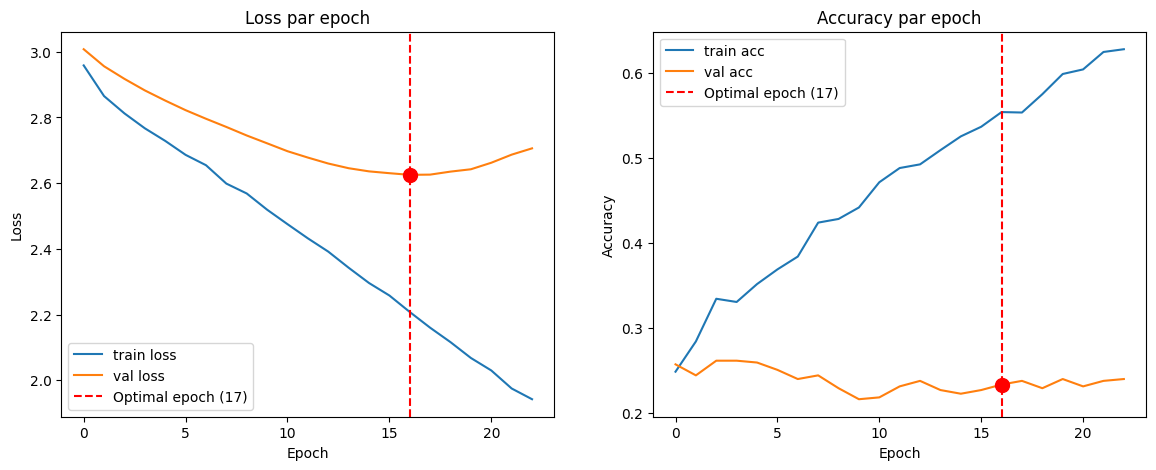

CPU times: total: 141 ms
Wall time: 135 ms


In [16]:
%%time

evaluation(history_finetuned)

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 189ms/step


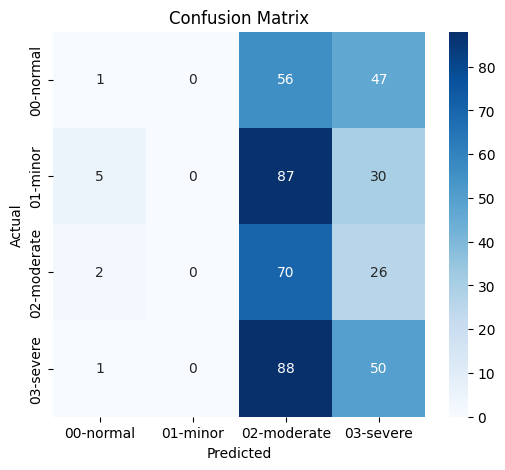

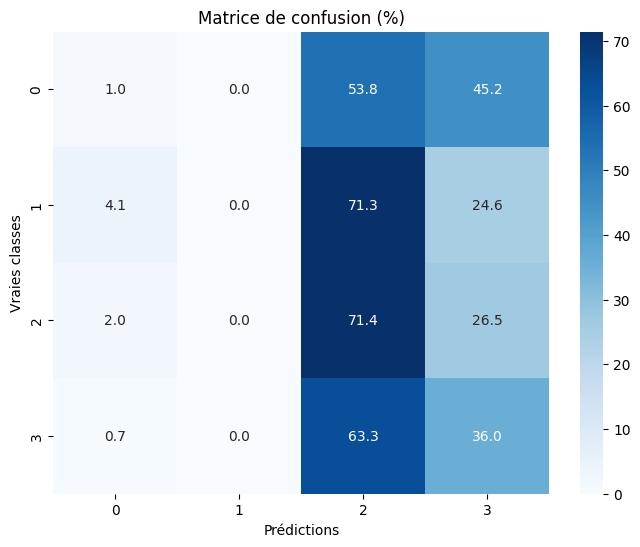


📄 Rapport de classification détaillé :

              precision    recall  f1-score   support

   00-normal      0.111     0.010     0.018       104
    01-minor      0.000     0.000     0.000       122
 02-moderate      0.233     0.714     0.351        98
   03-severe      0.327     0.360     0.342       139

    accuracy                          0.261       463
   macro avg      0.168     0.271     0.178       463
weighted avg      0.172     0.261     0.181       463

CPU times: total: 27.3 s
Wall time: 3.64 s


c:\Users\huber_otpq54a\OneDrive\Documents\Formation\IA\Developpement\Projets\Deep_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\huber_otpq54a\OneDrive\Documents\Formation\IA\Developpement\Projets\Deep_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\huber_otpq54a\OneDrive\Documents\Formation\IA\Developpement\Projets\Deep_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and

In [17]:

%%time

matrice_confusion(model_finetuned, val_ds_prepared)

<div style="background-color:#FFECB3; color:black; padding:10px; border-radius:5px;">

Sauvegarde de cette version du modèle<br>

</div>

In [18]:
%%time

# Sauvegarde du modèle

# Sauvegarder au format Keras (.keras)
model_path = NOTEBOOK_NAME + '.keras'
model_finetuned.save(model_path)

with open("mobilenetv2_class_names.json", "w") as f:
    json.dump(class_names, f)

print(f"\n✅ Modèle sauvegardé : {model_path}")
print(f"   Taille du fichier : {os.path.getsize(model_path) / (1024**2):.1f} MB")

# Sauvegarder aussi au format h5 (legacy)
model_h5_path = NOTEBOOK_NAME + '.h5'
model_finetuned.save(model_h5_path)
print(f"\n✅ Modèle également sauvegardé en .h5 : {model_h5_path}")


# Pour recharger le modèle
# loaded_model = keras.models.load_model(model_path)



✅ Modèle sauvegardé : car-damage-severity-mobilenetv2 classique V1.keras
   Taille du fichier : 27.2 MB

✅ Modèle également sauvegardé en .h5 : car-damage-severity-mobilenetv2 classique V1.h5
CPU times: total: 531 ms
Wall time: 570 ms


<div style="background-color:#FFECB3; color:black; padding:10px; border-radius:5px;">

Test de cette version du modèle<br>

</div>

---------------------------------------
# Test
---------------------------------------

In [19]:
%%time

# Fonction de prédiction

def predict_image(model, image_path, class_names):
    
    # Charger et prétraiter l'image
    img = load_img(image_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # Ajouter dimension batch
    img_array = preprocess_input(img_array)  # Normalisation MobileNetV2
    
    # Prédire
    predictions = model.predict(img_array, verbose=0)
    predicted_class_idx = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class_idx]
    
    # Top 3 prédictions
    top3_idx = np.argsort(predictions[0])[-3:][::-1]
    
    return {
        'predicted_class': class_names[predicted_class_idx],
        'confidence': confidence,
        'all_probabilities': predictions[0],
        'top3': [(class_names[i], predictions[0][i]) for i in top3_idx]
    }

print("✅ Fonction de prédiction créée !")

✅ Fonction de prédiction créée !
CPU times: total: 0 ns
Wall time: 0 ns


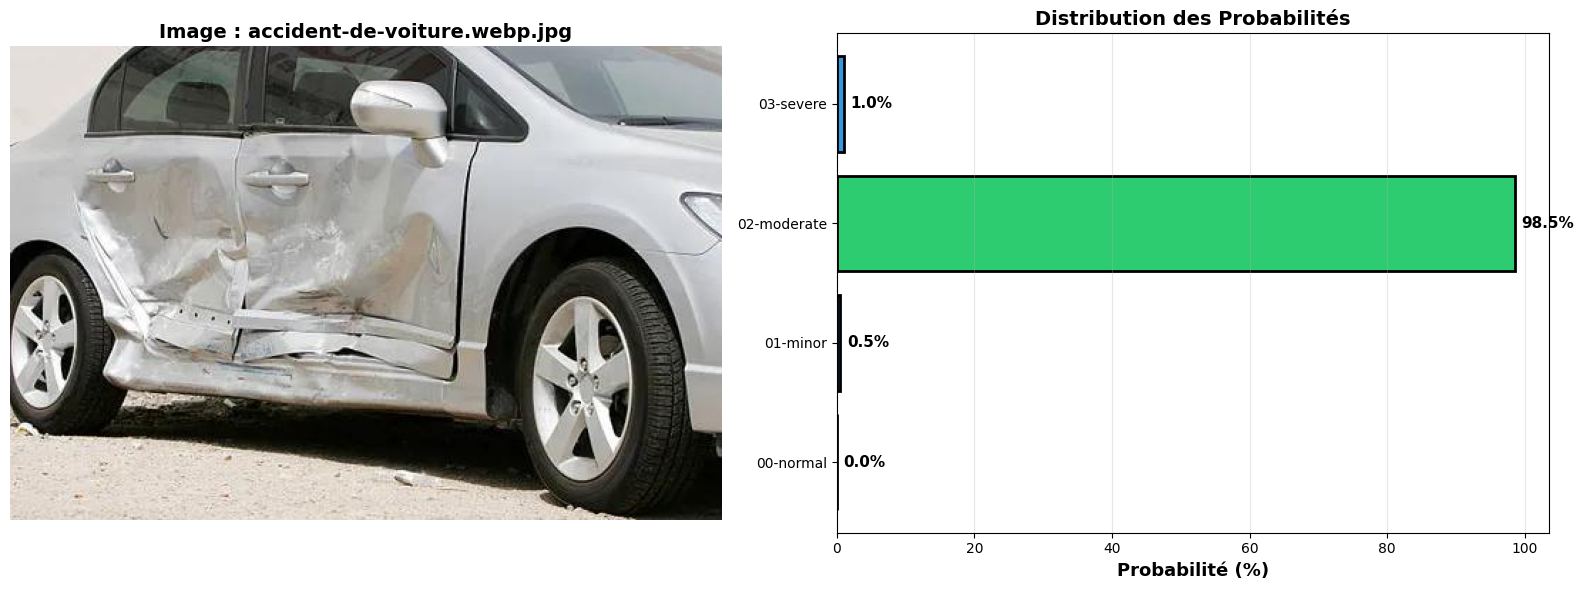


🔍 Analyse de la prédiction :
  - Classe prédite : 02-moderate
  - Confiance      : 98.53%

  - Top 3 prédictions :
    1. 02-moderate     : 98.53%
    2. 03-severe       : 1.01%
    3. 01-minor        : 0.46%
CPU times: total: 1.69 s
Wall time: 1.71 s


In [20]:
%%time

model_path = 'mobilenetv2_test1_finetuned.keras'
loaded_model = keras.models.load_model(model_path)
class_names = ["00-normal", "01-minor", "02-moderate", "03-severe"]

# Visualisation des probabilités pour une image

from PIL import Image

# Prendre une image spécifique
sample_image_path = "C:/Users/huber_otpq54a/OneDrive/Documents/Formation/IA/Developpement/Projets/Deep_Learning/Test/accident-de-voiture.webp"

im = Image.open(sample_image_path).convert("RGB")
sample_image_path = sample_image_path + ".jpg"
im.save(sample_image_path, "JPEG")

result = predict_image(loaded_model, sample_image_path, class_names)

# Visualiser
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Image
img = plt.imread(sample_image_path)
axes[0].imshow(img)
axes[0].axis('off')
axes[0].set_title(f"Image : {str(Path(sample_image_path).name)}", fontsize=14, fontweight='bold')

# Probabilités
probs = result['all_probabilities'] * 100
colors = ['#2ecc71' if i == np.argmax(probs) else '#3498db' for i in range(len(probs))]

bars = axes[1].barh(class_names, probs, color=colors, edgecolor='black', linewidth=2)
axes[1].set_xlabel('Probabilité (%)', fontsize=13, fontweight='bold')
axes[1].set_title('Distribution des Probabilités', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3, axis='x')

# Ajouter les valeurs
for bar, prob in zip(bars, probs):
    width = bar.get_width()
    axes[1].text(width + 1, bar.get_y() + bar.get_height()/2.,
                f'{prob:.1f}%',
                ha='left', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n🔍 Analyse de la prédiction :")
print(f"  - Classe prédite : {result['predicted_class']}")
print(f"  - Confiance      : {result['confidence']*100:.2f}%")
print(f"\n  - Top 3 prédictions :")
for i, (cls, prob) in enumerate(result['top3'], 1):
    print(f"    {i}. {cls:15s} : {prob*100:.2f}%")